In [1]:
import os
import glob

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.9,
})

In [2]:
# Make model family and size specs configurable here.
# MODEL_WL = [8,16,32,64]
MODEL_WL = [64]
MODEL_FAMILY_PREFIX = 'corpus_full'
MODEL_SUFFIX_KNN_TEMPLATE = '{prefix}_317M_05_19_wl_{wl}_KNN_model'
MODEL_SUFFIX_KMEANS_TEMPLATE = '{prefix}_317M_05_19_wl_{wl}_Kmeans_model'
METHOD_LABEL = 'spaGFM'
SHOW_METHOD_WALK_LENGTH_IN_LEGEND = False
METHOD_COLOR = '#F2A1A7'
BASELINE_STYLE = {
    'scGPT-spatial': {'color': '#C9B6E4', 'linestyle': '-'},
    'Nicheformer': {'color': '#7DC69B', 'linestyle': '-'},
    'Novae': {'color': '#9BD7F3', 'linestyle': '-'},
}

# Baselines are now fully configurable by prefix.
BASELINE_KEY_TEMPLATE = '{prefix}'
BASELINE_FOLDER_KNN_TEMPLATE = '{prefix}_KNN_model{suffix}'
BASELINE_FOLDER_KMEANS_TEMPLATE = '{prefix}_Kmeans_model{suffix}'

BASELINE_PREFIX_TO_LABEL = {
    'scgpt_spatial_emb': 'scGPT-spatial',
    'nicheformer_emb': 'Nicheformer',
    'novae_emb': 'Novae',
}

RESOURCES = [
    {
        'name': 'Human Lung',
        'base_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Lung_benchmark/baseline_dir/05_19_26',
        'g2pm_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Lung_benchmark/g2pm_dir/05_19_26',
    },

    {
        'name': 'Human Liver',
        'base_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Liver_benchmark/baseline_dir/05_19_26',
        'g2pm_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Liver_benchmark/g2pm_dir/05_19_26',
    },

    {
        'name': 'Human Cortex',
        'base_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Cortex_benchmark/baseline_dir/05_19_26',
        'g2pm_dir': '/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Cortex_benchmark/g2pm_dir/05_19_26',
    },
]

TASKS = {
    'Niche task': {
        'suffix': '_niche',
        'title': 'Niche task',
    },
    'Cell type task': {
        'suffix': '_ct',
        'title': 'Cell type task',
    },
}

In [3]:
# Debug: inspect one metrics file to confirm format.
sample_metric_path = (
    "/fs/ess/PAS1475/yzhong/sf_project/scripts/"
    "CosMx_Lung_benchmark/g2pm_dir/05_19_26/"
    "corpus_full_317M_05_19_wl_8_KNN_model_niche/"
    "step_150000_knn_node_spaGFM_acc_macro_stat.pt"
 )
sample_loaded = torch.load(sample_metric_path, map_location="cpu", weights_only=False)
print(type(sample_loaded))
if isinstance(sample_loaded, dict):
    print("keys:", list(sample_loaded.keys())[:5])
    first_val = next(iter(sample_loaded.values()))
    print("first value type:", type(first_val))
    if isinstance(first_val, dict):
        print("first value keys:", list(first_val.keys()))

<class 'dict'>
keys: ['Lung12', 'Lung13', 'Lung5_Rep1', 'Lung5_Rep2', 'Lung5_Rep3']
first value type: <class 'dict'>
first value keys: ['train', 'train_std', 'val', 'val_std', 'test', 'test_std', 'metric']


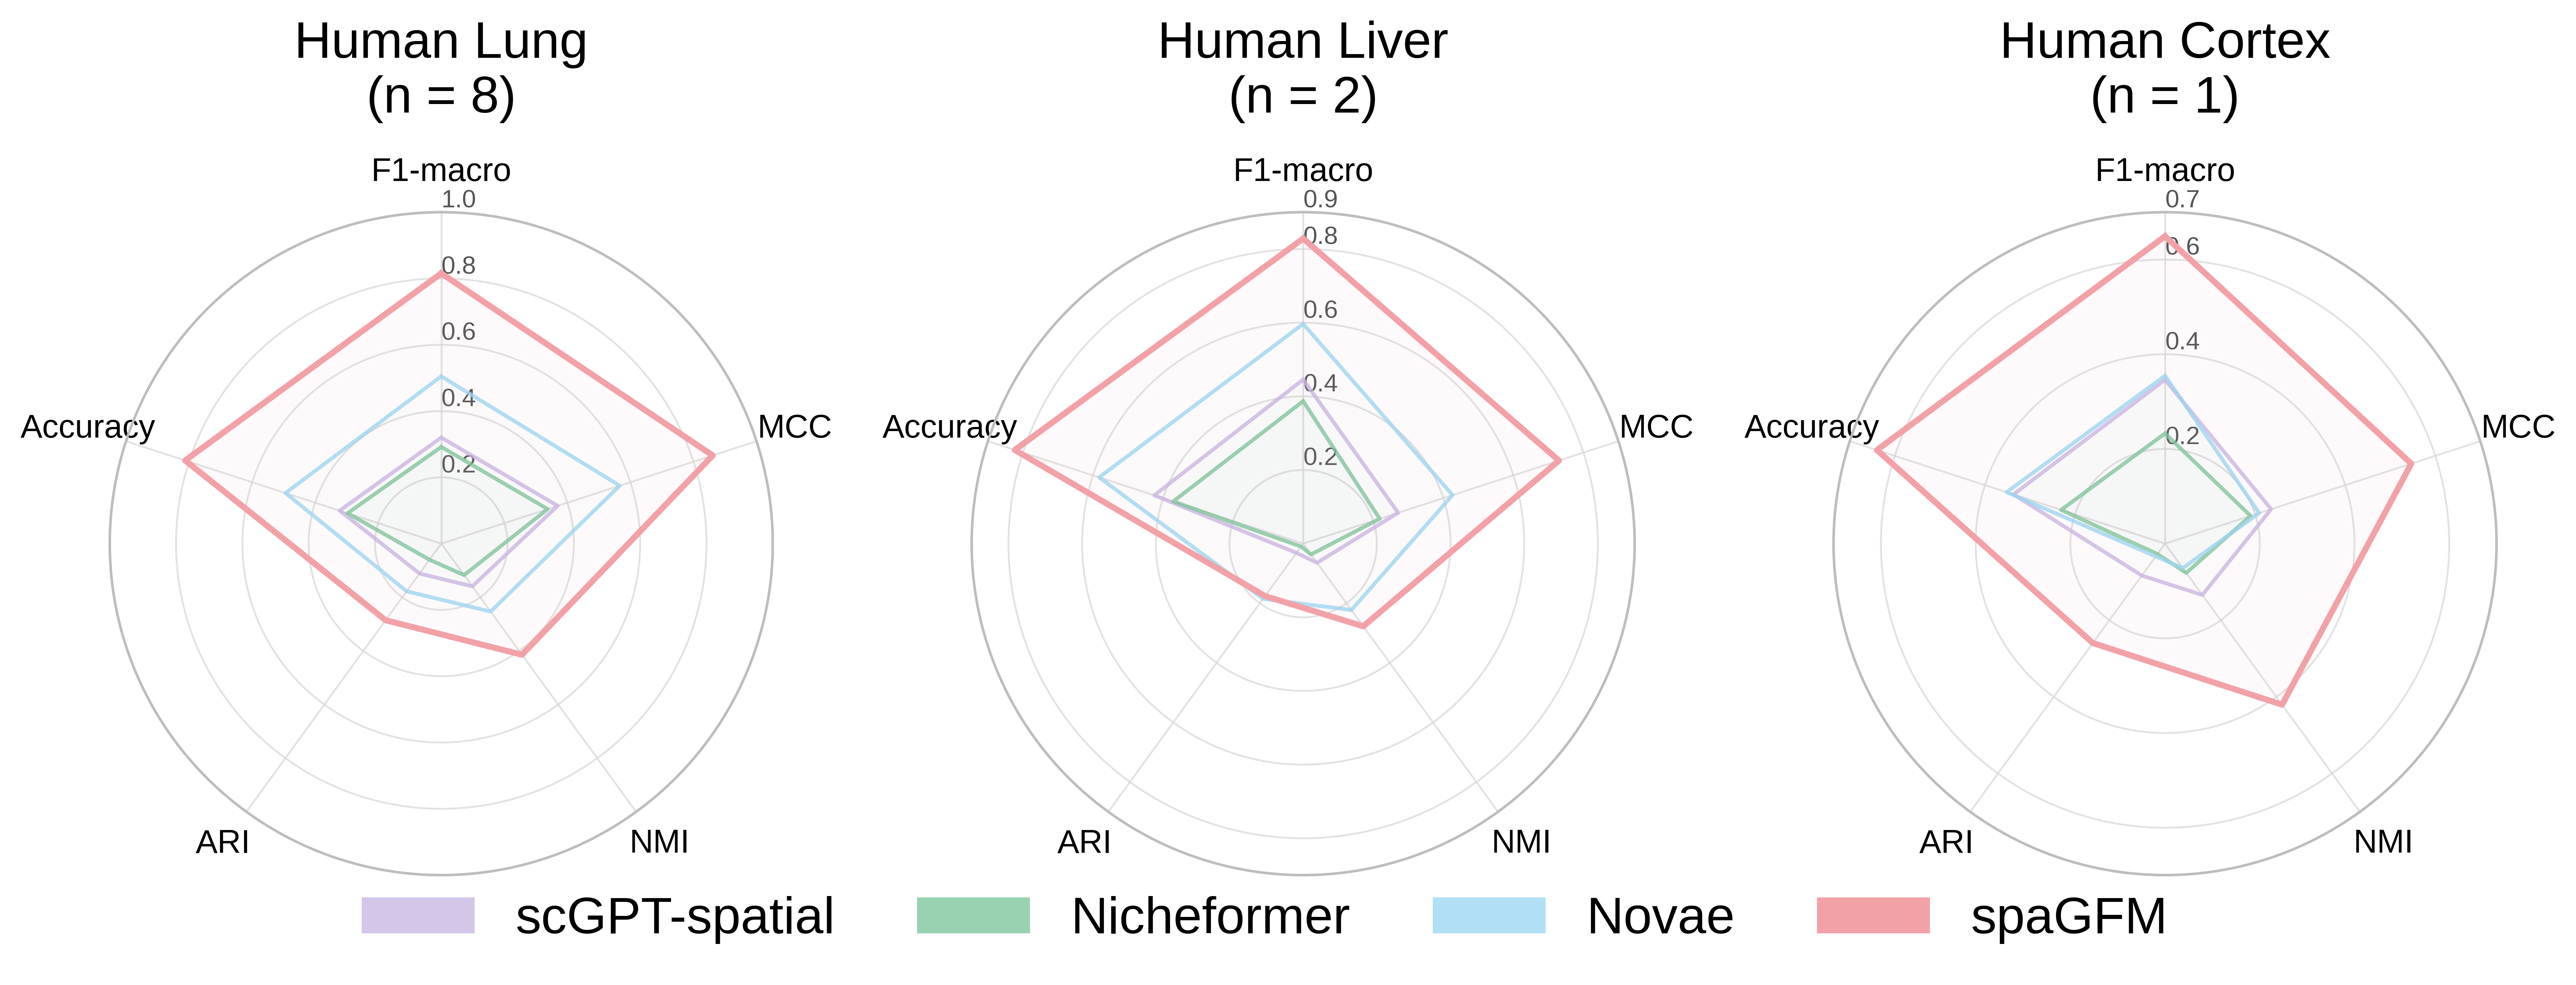

[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Lung_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_KNN_model_ct
[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Lung_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_Kmeans_model_ct
[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Liver_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_KNN_model_ct
[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Liver_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_Kmeans_model_ct
[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Cortex_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_KNN_model_ct
[skip] Missing model dir: /fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Cortex_benchmark/g2pm_dir/05_19_26/corpus_full_317M_05_19_wl_64_Kmeans_model_ct


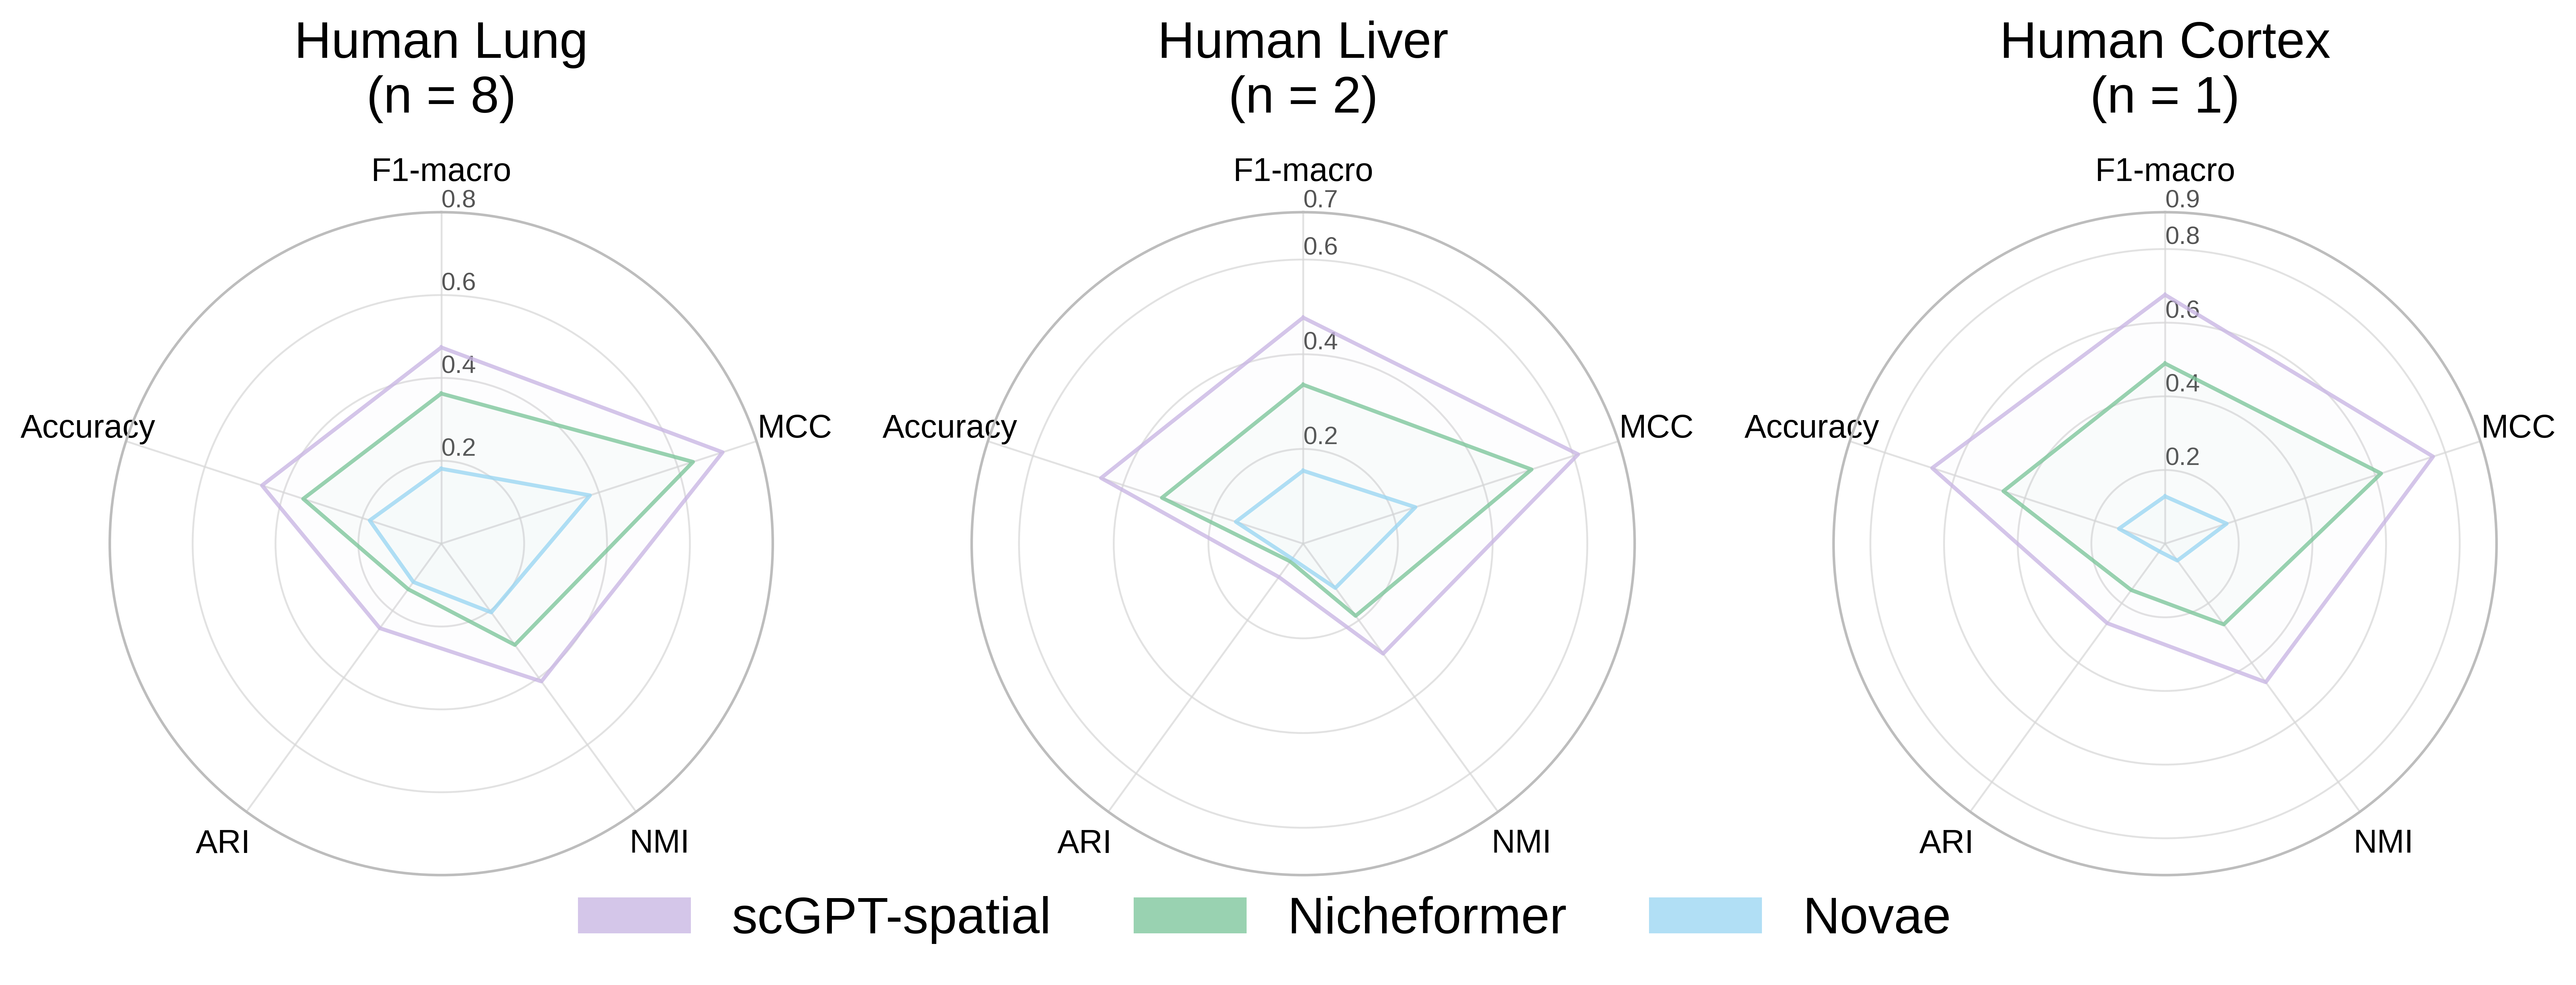

In [4]:
METRIC_VALUE_KEY = "test"
FALLBACK_VALUE_KEYS = ["val", "metric", "value", "best", "score"]


def extract_metric_name(path):
    name = os.path.basename(path)
    if "spaGFM_" in name:
        name = name.split("spaGFM_")[-1]
    if name.endswith("_stat.pt"):
        name = name[: -len("_stat.pt")]
    return name


def _extract_scalar(obj):
    if obj is None:
        return None
    if isinstance(obj, (int, float, np.integer, np.floating)):
        return float(obj)
    if torch.is_tensor(obj):
        if obj.numel() == 1:
            return float(obj.item())
        return float(obj.mean().item())
    if isinstance(obj, (list, tuple)):
        values = [_extract_scalar(v) for v in obj]
        values = [v for v in values if v is not None]
        return float(np.mean(values)) if values else None
    return None


def _mean_if_possible(values):
    values = [v for v in values if v is not None]
    return float(np.mean(values)) if values else None


def extract_metric_value(loaded, dataset_name, value_key=METRIC_VALUE_KEY):
    scalar = _extract_scalar(loaded)
    if scalar is not None:
        return scalar
    if isinstance(loaded, dict):
        value_dicts = [v for v in loaded.values() if isinstance(v, dict)]
        if value_dicts and any(value_key in v for v in value_dicts):
            values = [extract_metric_value(v, dataset_name, value_key) for v in value_dicts]
            return _mean_if_possible(values)
        if value_key in loaded:
            return _extract_scalar(loaded[value_key])
        for key in FALLBACK_VALUE_KEYS:
            if key in loaded:
                value = _extract_scalar(loaded[key])
                if value is not None:
                    return value
        values = [extract_metric_value(v, dataset_name, value_key) for v in loaded.values()]
        return _mean_if_possible(values)
    return None


def _has_metric_value(metric_dict, value_key=METRIC_VALUE_KEY):
    if not isinstance(metric_dict, dict):
        return False
    for key in [value_key, *FALLBACK_VALUE_KEYS]:
        if key in metric_dict and _extract_scalar(metric_dict[key]) is not None:
            return True
    return False


def _extract_dataset_names(loaded, value_key=METRIC_VALUE_KEY):
    if not isinstance(loaded, dict):
        return set()
    dataset_names = {
        str(key)
        for key, value in loaded.items()
        if _has_metric_value(value, value_key)
    }
    if dataset_names:
        return dataset_names
    nested_dataset_names = set()
    for value in loaded.values():
        nested_dataset_names.update(_extract_dataset_names(value, value_key))
    return nested_dataset_names


def load_metrics_from_dir(model_dir, dataset_name):
    pattern = os.path.join(model_dir, "*_stat.pt")
    metrics_by_name = {}
    dataset_names = set()
    for path in sorted(glob.glob(pattern)):
        metric_name = extract_metric_name(path)
        loaded = torch.load(path, map_location="cpu", weights_only=False)
        dataset_names.update(_extract_dataset_names(loaded))
        value = extract_metric_value(loaded, dataset_name)
        if value is None:
            raise ValueError(f"Cannot extract scalar from {path} for {dataset_name}")
        metrics_by_name.setdefault(metric_name, []).append(value)
    if not metrics_by_name:
        raise FileNotFoundError(f"No metrics found in {model_dir}")
    metrics = {
        metric_name: _mean_if_possible(values)
        for metric_name, values in metrics_by_name.items()
    }
    return metrics, dataset_names


def _safe_load_model(model_dir, dataset_name):
    if not os.path.isdir(model_dir):
        print(f"[skip] Missing model dir: {model_dir}")
        return None
    try:
        return load_metrics_from_dir(model_dir, dataset_name)
    except FileNotFoundError:
        print(f"[skip] Missing metrics in: {model_dir}")
        return None


def _merge_metric_dicts(metric_dicts):
    if not metric_dicts:
        return {}
    metric_names = sorted({
        metric
        for metrics in metric_dicts
        for metric in metrics.keys()
    })
    merged = {}
    for metric in metric_names:
        values = [metrics.get(metric) for metrics in metric_dicts]
        merged[metric] = _mean_if_possible(values)
    return merged


def collect_dataset_metrics(task_suffix):
    dataset_results = []
    for resource in RESOURCES:
        dataset_name = resource["name"]
        per_model_metrics = {}
        source_dataset_names = set()
        for prefix, label in BASELINE_PREFIX_TO_LABEL.items():
            baseline_key = BASELINE_KEY_TEMPLATE.format(prefix=prefix)
            for variant_label, baseline_template in (
                ("KNN", BASELINE_FOLDER_KNN_TEMPLATE),
                ("Kmeans", BASELINE_FOLDER_KMEANS_TEMPLATE),
            ):
                folder_name = baseline_template.format(prefix=baseline_key, suffix=task_suffix)
                model_dir = os.path.join(resource["base_dir"], folder_name)
                loaded_model = _safe_load_model(model_dir, dataset_name)
                if loaded_model is not None:
                    metrics, dataset_names = loaded_model
                    source_dataset_names.update(dataset_names)
                    per_model_metrics.setdefault(label, {}).setdefault(variant_label, []).append(metrics)
        for wl in MODEL_WL:
            for variant_label, method_template in (
                ("KNN", MODEL_SUFFIX_KNN_TEMPLATE),
                ("Kmeans", MODEL_SUFFIX_KMEANS_TEMPLATE),
            ):
                method_folder = method_template.format(prefix=MODEL_FAMILY_PREFIX, wl=wl) + task_suffix
                method_dir = os.path.join(resource["g2pm_dir"], method_folder)
                loaded_model = _safe_load_model(method_dir, dataset_name)
                if loaded_model is not None:
                    metrics, dataset_names = loaded_model
                    source_dataset_names.update(dataset_names)
                    method_label = f"{METHOD_LABEL}-{wl}"
                    per_model_metrics.setdefault(method_label, {}).setdefault(variant_label, []).append(metrics)
        models = []
        for label, variants in per_model_metrics.items():
            knn_metrics = _merge_metric_dicts(variants.get("KNN", []))
            kmeans_metrics = _merge_metric_dicts(variants.get("Kmeans", []))
            if knn_metrics or kmeans_metrics:
                models.append((label, {"KNN": knn_metrics, "Kmeans": kmeans_metrics}))
        if not models:
            raise FileNotFoundError(f"No models found for {dataset_name} {task_suffix}")
        dataset_count = len(source_dataset_names) if source_dataset_names else None
        dataset_results.append({"name": dataset_name, "dataset_count": dataset_count, "models": models})
    return dataset_results


def _collect_metric_names(dataset_results, variant_label):
    return sorted({
        metric
        for dataset in dataset_results
        for _, metrics in dataset["models"]
        for metric in metrics[variant_label].keys()
    })


def _wl_alpha_map():
    if not MODEL_WL:
        return {}
    min_alpha, max_alpha = 0.25, 1.0
    if len(MODEL_WL) == 1:
        return {MODEL_WL[0]: max_alpha}
    wl_min, wl_max = min(MODEL_WL), max(MODEL_WL)
    alpha_map = {}
    for wl in MODEL_WL:
        ratio = (wl - wl_min) / (wl_max - wl_min) if wl_max != wl_min else 1.0
        alpha_map[wl] = min_alpha + (max_alpha - min_alpha) * ratio
    return alpha_map


def _label_alpha(label, wl_alpha):
    if label.startswith(f"{METHOD_LABEL}-"):
        wl_text = label.split('-', 1)[1]
        try:
            wl = int(wl_text)
        except ValueError:
            return 0.6
        return wl_alpha.get(wl, 0.6)
    return 0.78



def _model_style(label):

    if label.startswith(f"{METHOD_LABEL}-"):

        return {'color': METHOD_COLOR, 'linestyle': '-', 'linewidth': 2.1, 'zorder': 4}

    style = BASELINE_STYLE.get(label, {'color': '#7A7A7A', 'linestyle': '-'})

    return {'color': style['color'], 'linestyle': style['linestyle'], 'linewidth': 1.35, 'zorder': 3}



def _legend_label(label):

    if label.startswith(f"{METHOD_LABEL}-") and not SHOW_METHOD_WALK_LENGTH_IN_LEGEND:

        return METHOD_LABEL

    return label


def _display_metric_name(metric_name):
    display_names = {
        'f1_macro': 'F1-macro',
        'mcc': 'MCC',
        'nmi': 'NMI',
        'ari': 'ARI',
        'acc_macro': 'Accuracy',
    }
    return display_names.get(metric_name.lower(), metric_name.replace('_', ' ').title())


def _rotate_metric_block(metric_names, preferred_first='f1'):
    if not metric_names:
        return metric_names
    preferred_first = preferred_first.lower()
    for idx, metric_name in enumerate(metric_names):
        if metric_name.lower().startswith(preferred_first):
            return metric_names[idx:] + metric_names[:idx]
    return metric_names


def _collect_plot_values(dataset_models, knn_metric_names, kmeans_metric_names):
    plot_values = []
    for _, metrics in dataset_models:
        values = [
            *[metrics["KNN"].get(metric, 0.0) for metric in knn_metric_names],
            *[metrics["Kmeans"].get(metric, 0.0) for metric in kmeans_metric_names],
        ]
        plot_values.extend(values)
    return plot_values


def _dataset_radial_limit(dataset_models, knn_metric_names, kmeans_metric_names, pad_ratio=0.05):
    all_values = []
    for _, metrics in dataset_models:
        all_values.extend(metrics["KNN"].get(metric_name, 0.0) for metric_name in knn_metric_names)
        all_values.extend(metrics["Kmeans"].get(metric_name, 0.0) for metric_name in kmeans_metric_names)
    best_value = max(all_values) if all_values else 0.0
    padded_value = best_value * (1.0 + pad_ratio)
    rounded_limit = np.ceil(padded_value * 10) / 10
    return min(max(rounded_limit, 0.2), 1.0)


def _radial_ticks(radial_limit, tick_step=0.2):
    ticks = np.arange(tick_step, radial_limit + tick_step / 2, tick_step).tolist()
    if not ticks or not np.isclose(ticks[-1], radial_limit):
        ticks.append(radial_limit)
    return [round(min(tick, radial_limit), 2) for tick in ticks]


def _ordered_metrics_for_layout(knn_metric_names, kmeans_metric_names):
    if len(knn_metric_names) == 3 and len(kmeans_metric_names) == 2:
        metric_lookup = {
            _display_metric_name(metric_name): metric_name
            for metric_name in [*knn_metric_names, *kmeans_metric_names]
        }
        preferred_order = ["F1-macro", "MCC", "NMI", "ARI", "Accuracy"]
        if all(metric_name in metric_lookup for metric_name in preferred_order):
            return [metric_lookup[metric_name] for metric_name in preferred_order]
    return [*knn_metric_names, *kmeans_metric_names]


def plot_radar_for_task(task_name, task_suffix):
    dataset_results = collect_dataset_metrics(task_suffix)
    knn_metric_names = _rotate_metric_block(_collect_metric_names(dataset_results, "KNN"))
    kmeans_metric_names = _rotate_metric_block(_collect_metric_names(dataset_results, "Kmeans"))
    ordered_metric_names = _ordered_metrics_for_layout(knn_metric_names, kmeans_metric_names)
    metric_names = [_display_metric_name(metric) for metric in ordered_metric_names]
    if not metric_names:
        raise ValueError("No metrics discovered for plotting")

    metric_angles = np.linspace(0, 2 * np.pi, len(ordered_metric_names), endpoint=False).tolist()
    plot_angles = metric_angles + metric_angles[:1]
    axis_labels = [_display_metric_name(metric_name) for metric_name in ordered_metric_names]

    num_datasets = len(dataset_results)
    fig, axes = plt.subplots(
        1,
        num_datasets,
        subplot_kw={"polar": True},
        figsize=(5.0 * num_datasets, 5.8),
        dpi=600,
    )
    if num_datasets == 1:
        axes = [axes]

    wl_alpha = _wl_alpha_map()
    for ax, dataset in zip(axes, dataset_results):
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        radial_limit = _dataset_radial_limit(dataset["models"], knn_metric_names, kmeans_metric_names)
        ax.set_ylim(0, radial_limit)
        ax.grid(color='#D8D8D8', linewidth=0.65, alpha=0.72)
        ax.spines['polar'].set_color('#BDBDBD')
        radial_ticks = _radial_ticks(radial_limit)
        radial_tick_labels = [f'{tick:.1f}' for tick in radial_ticks]

        for label, metrics in dataset["models"]:
            raw_value_map = {
                **{metric: metrics["KNN"].get(metric, 0.0) for metric in knn_metric_names},
                **{metric: metrics["Kmeans"].get(metric, 0.0) for metric in kmeans_metric_names},
            }
            raw_values = [raw_value_map[metric] for metric in ordered_metric_names]
            values = raw_values
            values += values[:1]
            alpha = _label_alpha(label, wl_alpha)
            style = _model_style(label)
            ax.plot(plot_angles, values, label=label, alpha=alpha, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'], zorder=style['zorder'])
            ax.fill(plot_angles, values, color=style['color'], alpha=0.045 if label.startswith(f"{METHOD_LABEL}-") else 0.025, zorder=style['zorder'] - 1)

        ax.set_xticks(metric_angles)
        ax.set_xticklabels(axis_labels, fontsize=11.5, fontweight='regular')
        ax.set_yticks(radial_ticks)
        ax.set_yticklabels(radial_tick_labels, fontsize=8.8, color='#555555')
        ax.set_rlabel_position(0)
        title = dataset["name"]
        if dataset.get("dataset_count") is not None:
            title = f'{title}\n(n = {dataset["dataset_count"]})'
        ax.set_title(title, pad=35, fontsize=18, fontweight='regular', linespacing=1.18)

    handles, labels = axes[0].get_legend_handles_labels()
    legend_handles = []
    legend_labels = []
    seen_labels = set()
    for label in labels:
        legend_label = _legend_label(label)
        if legend_label in seen_labels:
            continue
        seen_labels.add(legend_label)
        style = _model_style(label)
        legend_handles.append(Patch(facecolor=style['color'], edgecolor='none', alpha=_label_alpha(label, wl_alpha)))
        legend_labels.append(legend_label)
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        ncol=min(len(legend_labels), 4),
        bbox_to_anchor=(0.5, 0.1),
        frameon=False,
        fontsize=18.0,
        handlelength=2.2,
        columnspacing=1.6,
    )
    fig.subplots_adjust(top=0.83, bottom=0.12, wspace=0.30)
    output_dir = '/fs/ess/PAS1475/yzhong/sf_project/scripts/benchmark_results/05_19_26'
    output_stem = f"011_KNN_Kmeans_combined_view_datasets_{task_name.lower().replace(' ', '_')}_polished"
    fig.savefig(os.path.join(output_dir, f'{output_stem}_07_29.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(output_dir, f'{output_stem}_07_29.png'), dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)


for task_name, task_cfg in TASKS.items():
    plot_radar_for_task(task_name, task_cfg["suffix"])



